# MC simulations of structural transitions in a 2D system

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from tqdm import tqdm

### Workflow

- model particles
- create configuration 
- MC algorithm:
    1. Randomly select a particle m, with coordinate rm.
    2. Make a trial displacement, to an attempted coordinate rn: rn = rm + ∆∆∆, where ∆∆∆ is a
    random vector, usually constrained within some limits (see below).(xn = xm + ∆(ξx − 0.5)
yn = ym + ∆(ξy − 0.5))
    3. Calculate ∆U ≡ Un(r′N ; rn) − Um(rN ; rm).
        - Get distance between particles
        - Lennard Jones Potential: (r) = 4ϵ[( σ/r )12 − ( σ/r )6] 
    4. Accept the move if ξ < e−β∆U , where ξ is a random number (0 < ξ < 1), else retain the
    “old” coordinate. Note that a new random number has to be produced each time, i.e. ξ
    does not indicate a fixed number. If the move is accepted, update the coordinate for particle
    m, rm => rn, as well as the total energy (new energy: Un(r′N ; rn) = Um(rN ; rm) + ∆U ).
    5. Occasionally, i.e. with some chosen (usually low) frequency, sample averages.
    6. If the number of cycles is less than a chosen maximum, go back to entry 1; otherwise
    the simulation is finished, whereby averages are printed to some log file, and the final
    coordinates are saved on disk
- run until equilibrium is reached




In [ ]:
class Particles_2D():
    # sigma_0 = 1: bounding box abgeleitet davon und von ρ∗ ≡ N σ20 /L2

    def __init__(self,N,delta_step=0.5,sigma_0=1,epsilon=1.0,o=0.1):
        self.delta_step = delta_step
        self.sigma_0 = sigma_0 # define sigma_0 as our unit of length? --> create bounding box from it?
        self.sigma_1 = 2.5*sigma_0
        self.epsilon = epsilon
        self.N = N
        # sigma_0 = 1: bounding box abgeleitet davon und von ρ∗ ≡ N σ20 /L2 --> L = sqrt(N/o)
        self.LENGTH = np.sqrt(N/o)
        self.bounding_box =(self.LENGTH,self.LENGTH)
        self.con = np.random.uniform(0, self.LENGTH, size=(N, 2))
        self.energies = []

    def calc_U_1_particel(self,p_idx,p_new):
        dist = p_new - np.delete(self.con, p_idx, axis=0)
        #PBC condition
        dist = dist - np.round(dist/self.LENGTH)*self.LENGTH
        r = np.sqrt(dist[:,0]**2 + dist[:,1]**2)
        phi = np.where(
            r < self.sigma_0,
            np.inf,
            np.where(r < self.sigma_1, self.epsilon, 0)
        )
        u = np.sum(phi)
        return u
    
    def calc_U(self):
        u = 0
        for i in range(0, len(self.con) - 1):

            # x and y differences from particle i
            # to all particles after it
            dx = self.con[i, 0] - self.con[i + 1:, 0]
            dy = self.con[i, 1] - self.con[i + 1:, 1]

            # PBC condition
            dx = dx - self.LENGTH * np.round(dx / self.LENGTH)
            dy = dy - self.LENGTH * np.round(dy / self.LENGTH)

            # Distance
            r = np.sqrt(dx**2 + dy**2)

            
            phi = np.where(
                r < self.sigma_0,
                np.inf,
                np.where(r < self.sigma_1, self.epsilon, 0.0)
            )

            # Add energy
            u += np.sum(phi)

        return u

    def calc_new_pos(self,p):
        xi_rv = np.random.sample(2)
        p_new = p + self.delta_step*(xi_rv - 0.5) # add: box restriction
        p_new %= self.LENGTH
        return p_new
    
    def pre_run(self,n_pre,T_pre=1.0):
        self.run_mc(n_pre,T=T_pre)

    def equil_run(self,n_eq,T_star=0.1):
        self.run_mc(n_eq,T=T_star)
        
    def count_overlaps(self):
        overlaps = 0

        for i in range(self.N):
            for j in range(i + 1, self.N):

                dr = self.con[i] - self.con[j]
                r = np.linalg.norm(dr)

                if r < self.sigma_0:
                    overlaps += 1

        return overlaps
    
    def run_mc(self,max_iter,T=0.1,hotstart=False,cal_delta=False):
        
    
        print("Overlaps start:", self.count_overlaps())
        accept = 0
        plt.ion()

        fig, ax = plt.subplots(figsize=(6, 6))
        scatter = ax.scatter(self.con[:, 0], self.con[:, 1])

        ax.set_xlim(0, self.LENGTH)
        ax.set_ylim(0, self.LENGTH)
        ax.set_aspect("equal")
        plt.show(block=False)


        #β = 1/(kB T ), where kB is Boltzmann’s constant. 
                # T* = kT /ϵ = 0.1 --> β = 1/(T*ϵ)
        self.beta = 1/(T*self.epsilon)
        
        # calculate U once for all particles
        U_sum = self.calc_U()
        accept_loc = 0


        for i in tqdm(range(max_iter)):

            
            # 1. Randomly select a particle m, with coordinate rm.
            p_idx = np.random.choice(self.N)
            p = self.con[p_idx] #random particle with coordinates in p

            # 2. Make a trial displacement, to an attempted coordinate rn: rn = rm + ∆∆∆, where ∆∆∆ is a random vector
            p_new = self.calc_new_pos(p)      
            # 3. Calculate ∆U ≡ Un(r′N ; rn) − Um(rN ; rm).
            U_m = self.calc_U_1_particel(p_idx,p) 
            U_n = self.calc_U_1_particel(p_idx,p_new)
            
            if np.isinf(U_m):
                if np.isinf(U_n):
                    pass
                else:
                    self.con[p_idx] = p_new
                    accept += 1
                    accept_loc += 1
                    U_sum += U_n
            else:

                delta_U = U_n - U_m

                # 4. Accept the move if ξ < e−β∆U , where ξ is a random number (0 < ξ < 1), else retain the “old” coordinate.
                xi = np.random.random_sample(1)
                if xi < np.exp(-self.beta*delta_U):
                    accept += 1
                    accept_loc += 1
                    self.con[p_idx] = p_new
                    # new energy: Un(r′N ; rn) = Um(rN ; rm) + ∆U 
                    U_sum += delta_U

            if cal_delta and i % 500 == 0 and i > 0:

                ratio = accept_loc / 500

                if ratio > 0.7:
                    self.delta_step *= 1.1

                elif ratio < 0.25:
                    self.delta_step *= 0.9
                self.delta_step = min(self.delta_step, self.LENGTH)
                accept_loc = 0

            if i % 100 == 0:
                self.energies.append(U_sum)

            if i % 100000 == 0:
                U_sum = self.calc_U()

            if hotstart and i % 10000 == 0:
                U_sum = self.calc_U()
                ratio = accept/(i + 1)
                if not np.isinf(U_sum) and ratio < 0.7 and ratio > 0.25:
                    print("ratio: ",ratio )
                    print("Overlaps end: ",self.count_overlaps())
                    print("delta_step: ",self.delta_step)
                    return

            
            #     scatter.set_offsets(self.con)
            #     fig.canvas.draw()
            #     fig.canvas.flush_events()
            #     #plt.pause(0.01)
        # 30 -70% acceptance rate (choose delta accordingly)
        # 5. Occasionally, i.e. with some chosen (usually low) frequency, sample averages.

        # 6. If the number of cycles is less than a chosen maximum, go back to entry 1; otherwise
        # the simulation is finished, whereby averages are printed to some log file, and the final
        # coordinates are saved on disk
        ratio = accept/max_iter
        print("ratio: ",ratio )
        print("Overlaps end: ",self.count_overlaps())
        print("delta_step: ",self.delta_step)
        

        

## Trials

Overlaps start: 37


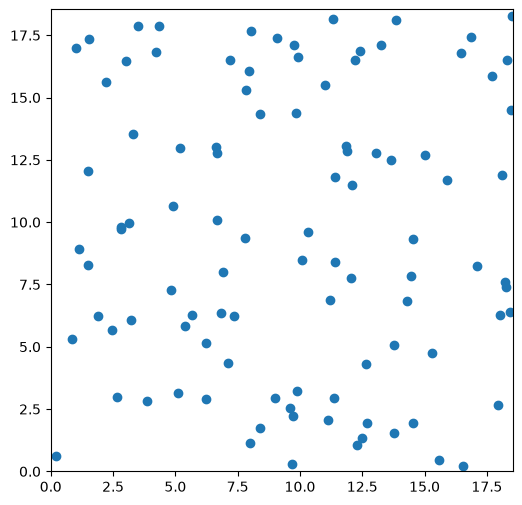

100%|██████████| 1000000/1000000 [01:36<00:00, 10377.57it/s]

ratio:  0.623243
Overlaps end:  11
delta_step:  0.8857805000000005


In [12]:
n_particels = 100
n_pre = 1000000
#n_mc = 10000
particels = Particles_2D(o=0.291,N=n_particels)
particels.run_mc(max_iter=n_pre,T=10.0,hotstart=True,cal_delta=True) #pre run
#particels.run_mc(n_mc)

Overlaps start: 11


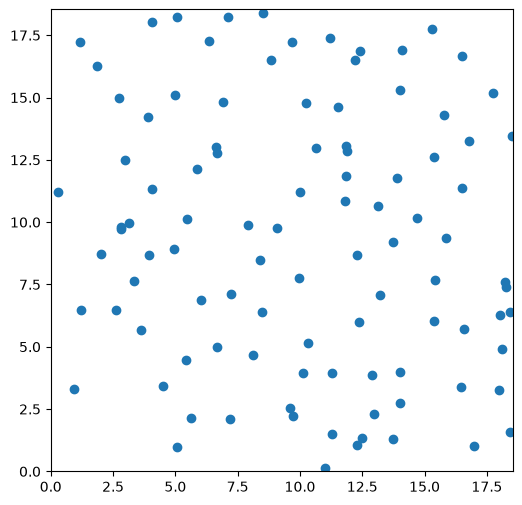

 32%|███▏      | 320000/1000000 [00:33<01:10, 9662.91it/s] 

ratio:  0.6325886481604746
Overlaps end:  0
delta_step:  1.4265583530550014


In [14]:
particels.run_mc(max_iter=n_pre,T=10.0,hotstart=True,cal_delta=True)

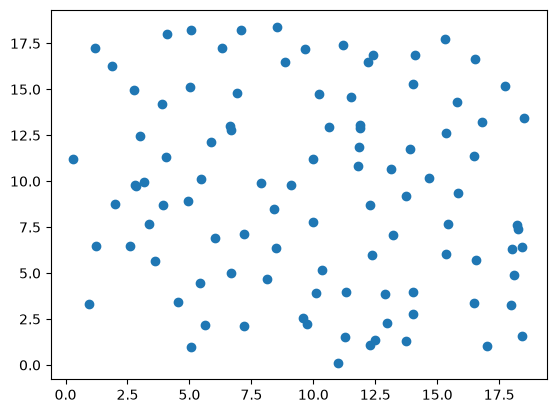

In [13]:
# plt.figure()
plt.scatter(particels.con[:,0],particels.con[:,1])
plt.show()

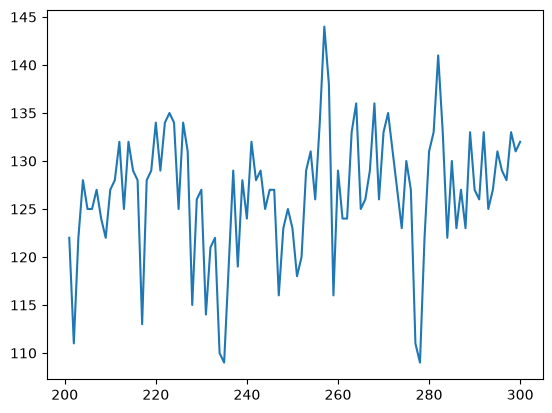

In [6]:
plt.figure()
plt.plot(range(len(particels.energies)),particels.energies)
plt.show()

In [227]:
reversed(np.arange(0.15,0.25))

In [235]:
np.arange(0.15,0.26,0.01)

array([0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22, 0.23, 0.24, 0.25,
       0.26])

Overlaps start: 0


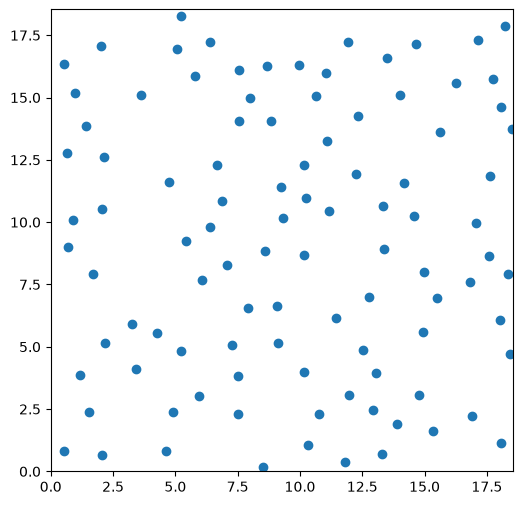

100%|██████████| 1000000/1000000 [03:35<00:00, 4635.67it/s]


ratio:  0.351656
Overlaps end:  0
delta_step:  0.36261199297478053
Overlaps start: 0


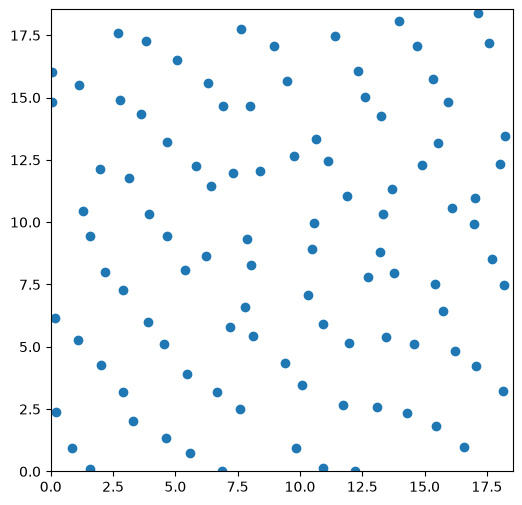

100%|██████████| 100000/100000 [00:26<00:00, 3785.91it/s]

ratio:  0.361
Overlaps end:  0
delta_step:  0.36261199297478053


In [15]:
t=0.19
steps_eq = 1000000
steps_prod = 100000
particels.energies = []
particels.run_mc(max_iter=steps_eq,cal_delta=True,T=t)
particels.run_mc(max_iter=steps_prod,T=t)



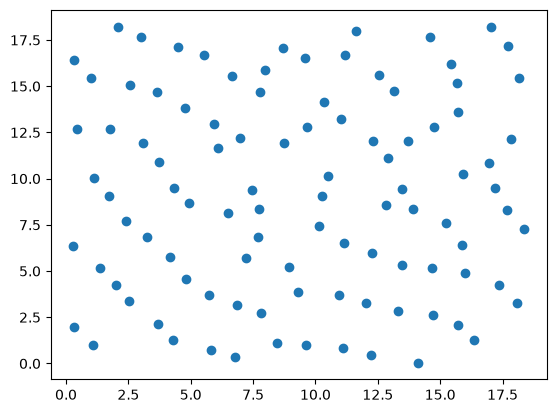

In [17]:
plt.figure()
plt.scatter(particels.con[:,0],particels.con[:,1])
plt.show()

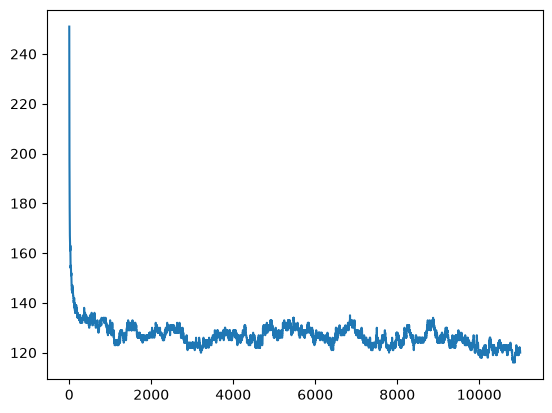

In [16]:
plt.figure()
plt.plot(range(len(particels.energies)),particels.energies)
plt.show()

Equilibrium run:
Overlaps start: 0


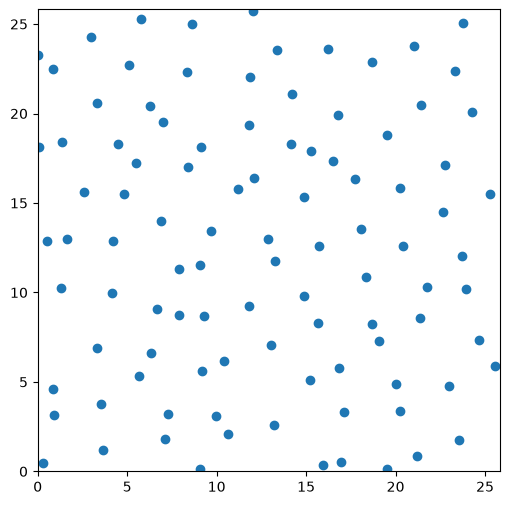

100%|██████████| 1000000/1000000 [01:31<00:00, 10934.28it/s]

ratio:  0.377746
Overlaps end:  0
delta_step:  1.0555803846466578


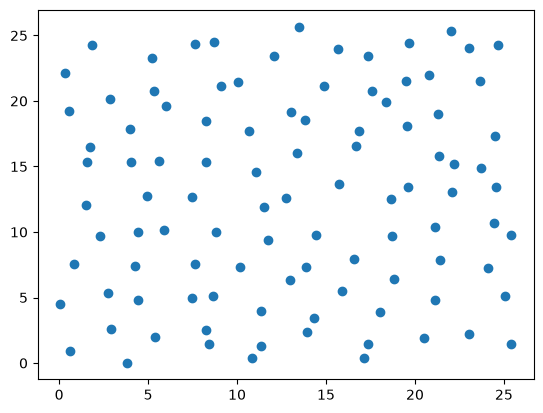

Production run: 
Overlaps start: 0


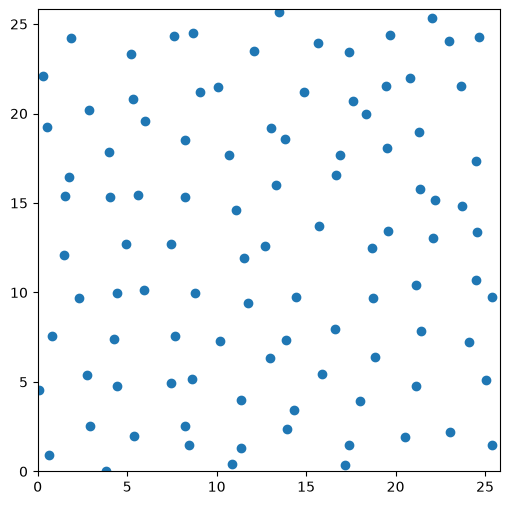

100%|██████████| 100000/100000 [00:08<00:00, 11296.64it/s]


ratio:  0.36905
Overlaps end:  0
delta_step:  1.0555803846466578


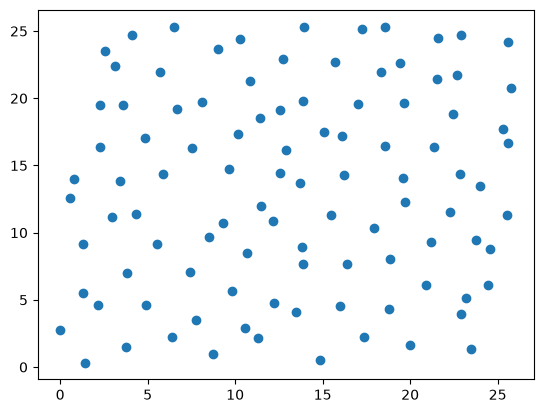

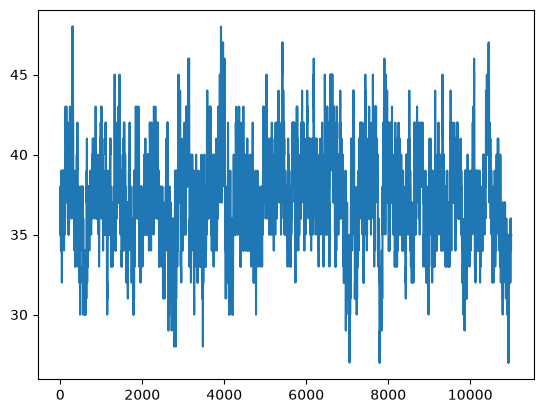

In [9]:
t=0.25
steps_eq = 1000000
steps_prod = 100000
print("Equilibrium run:")
particels.energies = []
particels.run_mc(max_iter=steps_eq,cal_delta=True,T=t)
plt.figure()
plt.scatter(particels.con[:,0],particels.con[:,1])
plt.show()  
print("Production run: ")
particels.run_mc(max_iter=steps_prod,T=t)
plt.figure()
plt.scatter(particels.con[:,0],particels.con[:,1])
plt.show()  
plt.figure()
plt.plot(range(len(particels.energies)),particels.energies)
plt.show()

Equilibrium run:
Overlaps start: 0


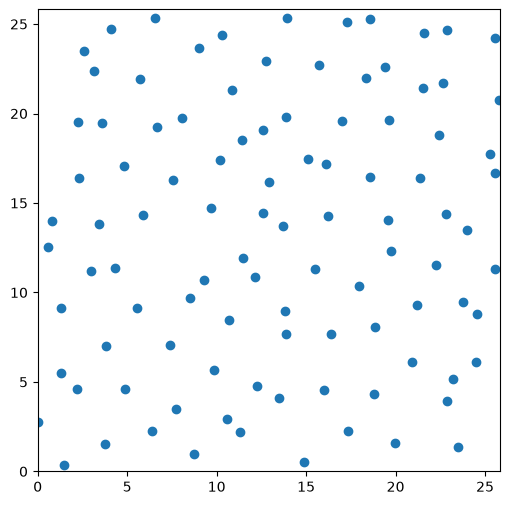

100%|██████████| 1000000/1000000 [01:35<00:00, 10524.99it/s]


ratio:  0.388094
Overlaps end:  0
delta_step:  0.9500223461819921
Production run: 
Overlaps start: 0


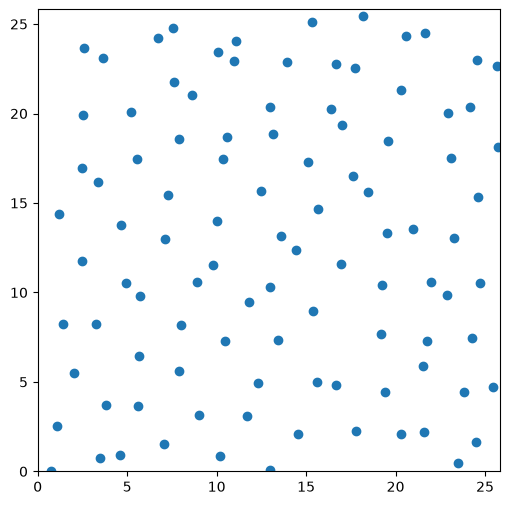

100%|██████████| 100000/100000 [00:12<00:00, 7968.59it/s]


ratio:  0.40625
Overlaps end:  0
delta_step:  0.9500223461819921


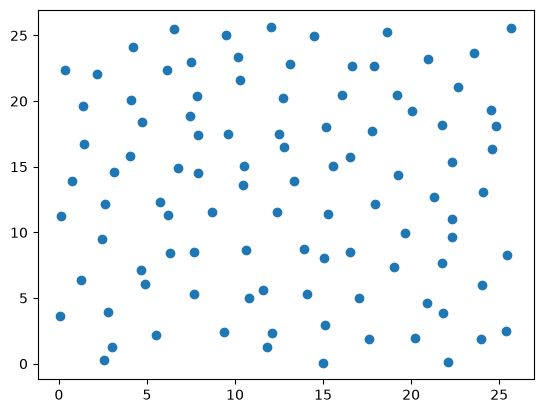

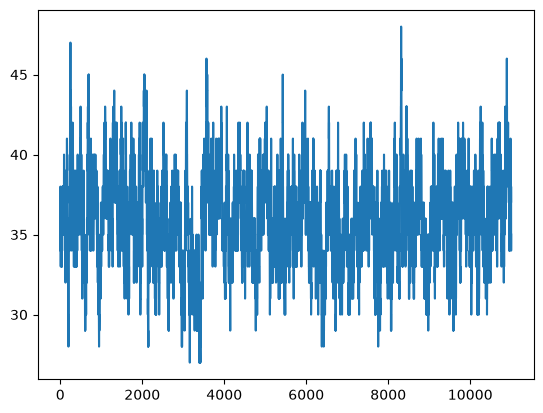

In [10]:
t=0.24
steps_eq = 1000000
steps_prod = 100000
print("Equilibrium run:")
particels.energies = []
particels.run_mc(max_iter=steps_eq,cal_delta=True,T=t)
print("Production run: ")
particels.run_mc(max_iter=steps_prod,T=t)
plt.figure()
plt.scatter(particels.con[:,0],particels.con[:,1])
plt.show()  
plt.figure()
plt.plot(range(len(particels.energies)),particels.energies)
plt.show()

Equilibrium run:
Overlaps start: 0


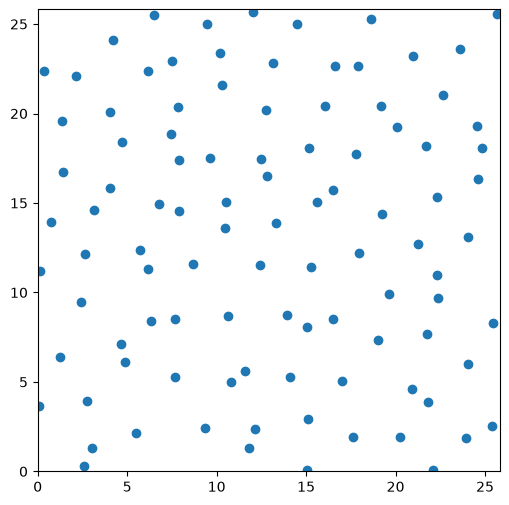

100%|██████████| 1000000/1000000 [01:40<00:00, 9995.28it/s]

ratio:  0.386485
Overlaps end:  0
delta_step:  0.9500223461819921


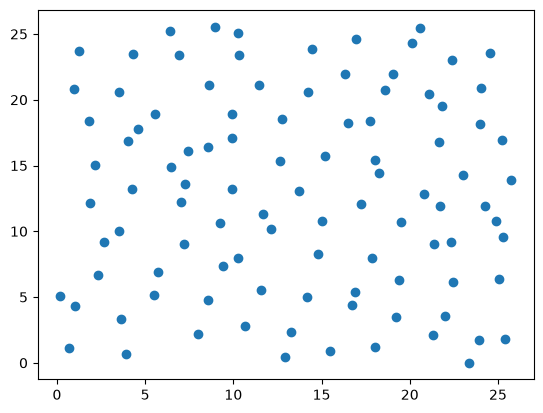

Production run: 
Overlaps start: 0


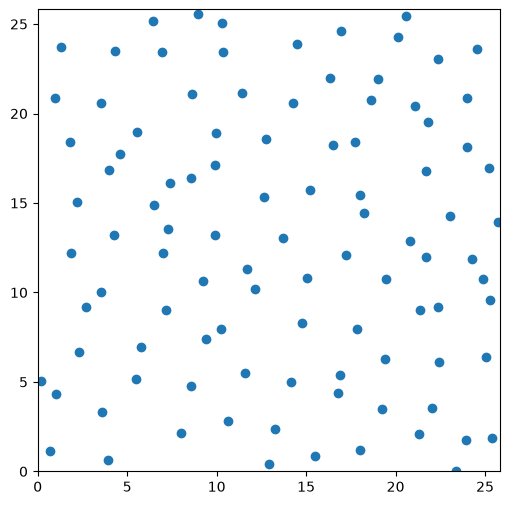

100%|██████████| 100000/100000 [00:09<00:00, 10718.49it/s]


ratio:  0.38697
Overlaps end:  0
delta_step:  0.9500223461819921


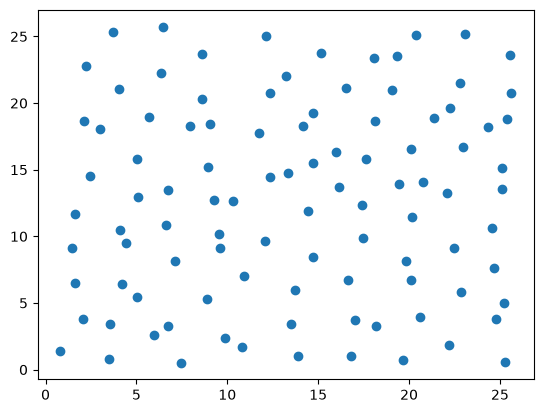

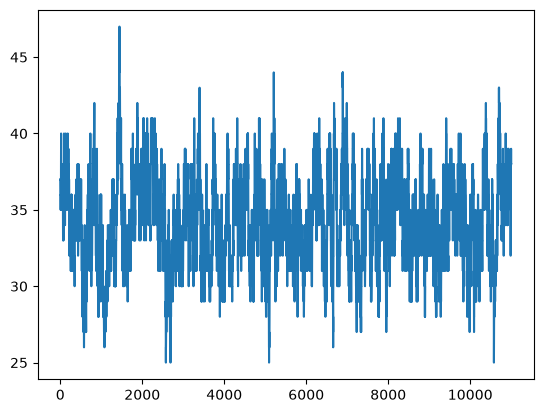

In [11]:
t=0.23
steps_eq = 1000000
steps_prod = 100000
print("Equilibrium run:")
particels.energies = []
particels.run_mc(max_iter=steps_eq,cal_delta=True,T=t)
plt.figure()
plt.scatter(particels.con[:,0],particels.con[:,1])
plt.show()  
print("Production run: ")
particels.run_mc(max_iter=steps_prod,T=t)
plt.figure()
plt.scatter(particels.con[:,0],particels.con[:,1])
plt.show()  
plt.figure()
plt.plot(range(len(particels.energies)),particels.energies)
plt.show()

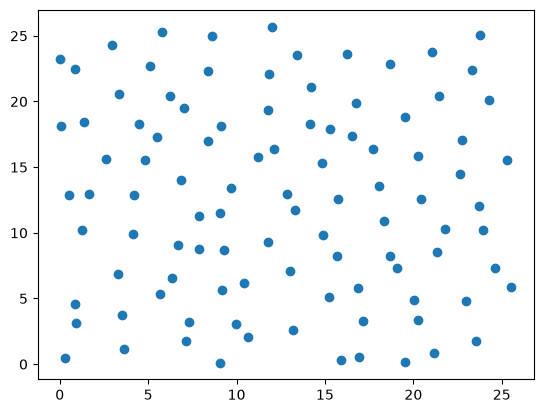

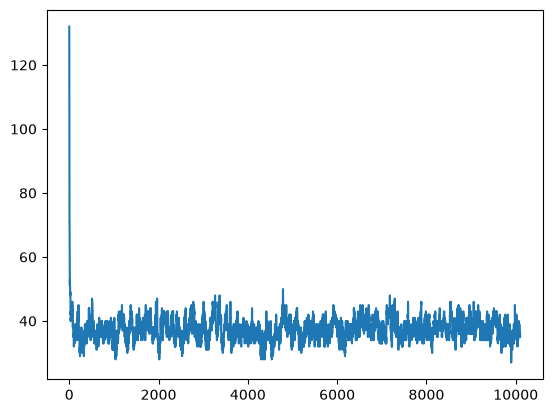

In [8]:
plt.figure()
plt.scatter(particels.con[:,0],particels.con[:,1])
plt.show()    
plt.figure()
plt.plot(range(len(particels.energies)),particels.energies)
plt.show()

Production run with Temperature 0.25
Overlaps start: 0


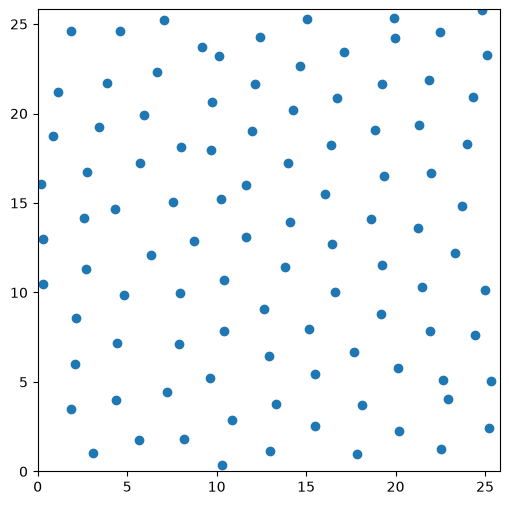

ratio:  0.123293
Overlaps end:  0
delta_step:  3.363749974662805


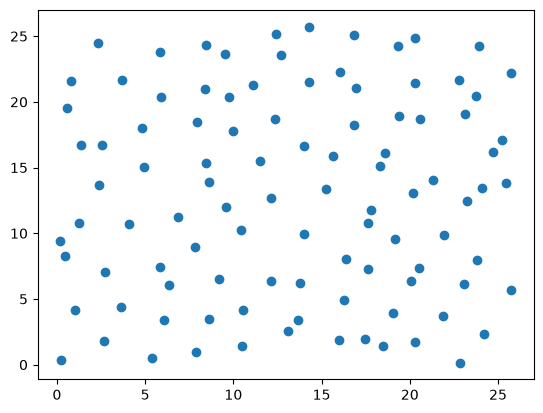

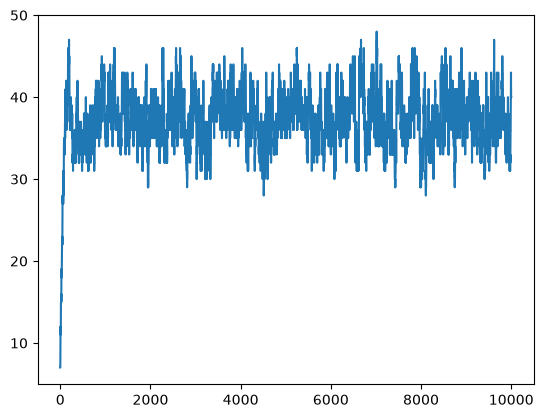

Production run with Temperature 0.24
Overlaps start: 0


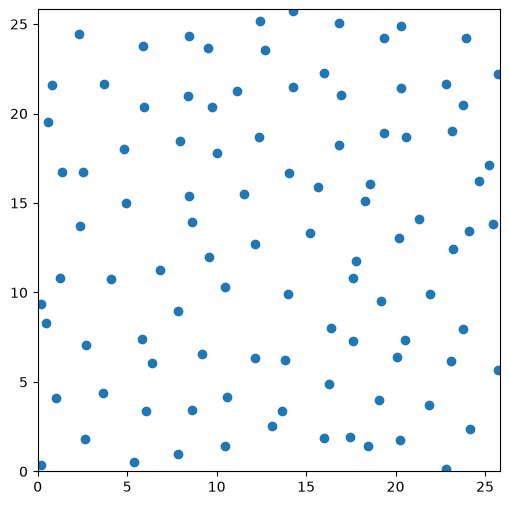

ratio:  0.114385
Overlaps end:  0
delta_step:  3.363749974662805


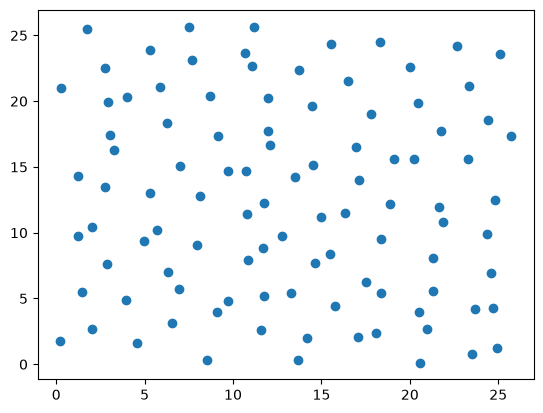

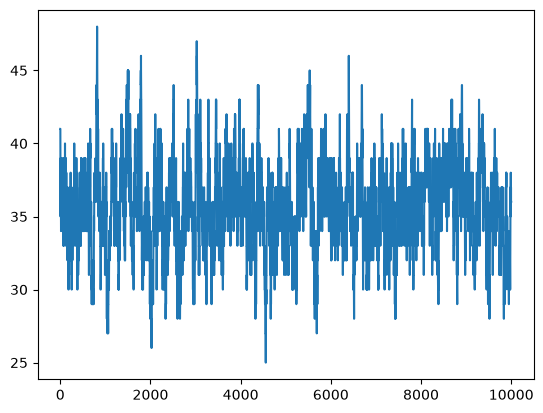

Production run with Temperature 0.22999999999999998
Overlaps start: 0


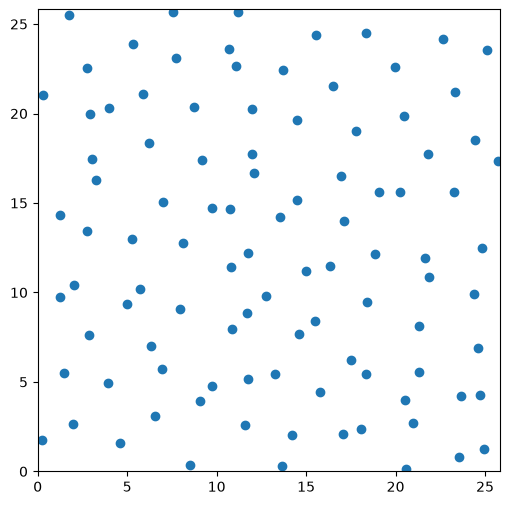

KeyboardInterrupt: 

In [237]:
t = 0.25
steps = 1000000
while t > 0.14:
    print(f"Production run with Temperature {t}")
    particels.energies = []
    particels.run_mc(max_iter=steps,calibration=False,T=t)
    plt.figure()
    plt.scatter(particels.con[:,0],particels.con[:,1])
    plt.show()    
    plt.figure()
    plt.plot(range(len(particels.energies)),particels.energies)
    plt.show()
    t -= 0.01

